In [12]:
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from tqdm import tqdm

from tools.constants import *
from tools.metrics import *
from tools.tools_plt import *
from tools.tools_rec import *
from tools.utils import load_data

obj_keys = ['object_mse', 'object_mse_nll']

SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# Initial object and probe

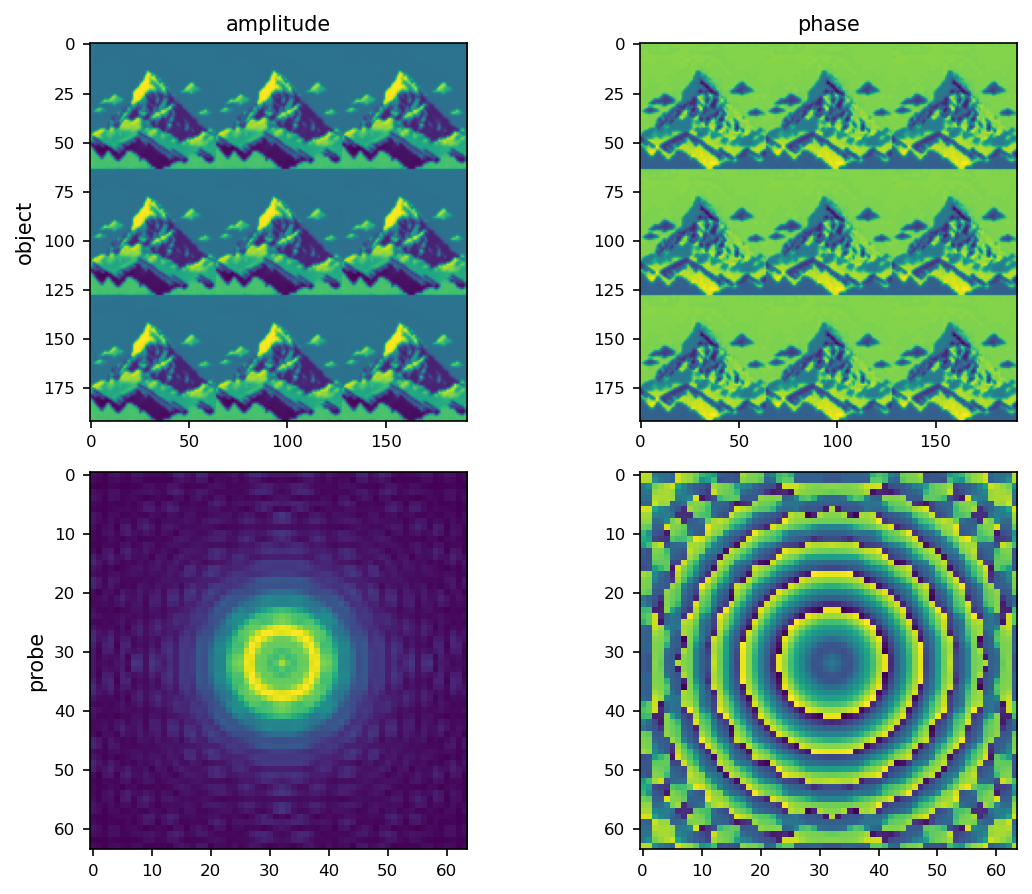

In [366]:
obj = simulate_object(PATH, resize=OBJ_SIZE, bc='periodic')
probe = simulate_probe(OBJ_SIZE, r_ratio=5, propagate=True, distance=60)

f, ax = plt.subplots(2, 2, figsize=(8, 6))
plot_amplitude(obj, ax[0, 0])
plot_phase(obj, ax[0, 1])
plot_amplitude(probe, ax[1, 0])
plot_phase(probe, ax[1, 1])
ax[0, 0].set_ylabel('object')
ax[1, 0].set_ylabel('probe')
ax[0, 0].set_title('amplitude')
ax[0, 1].set_title('phase')
f.tight_layout()

f.savefig('figures/initial_object_probe.png', bbox_inches='tight')

# Fluence

In [356]:
rec_dict = load_data('outputs/rec_fluence.pkl')
fluences = np.array(list(rec_dict['object_mse'].keys()))

mse_dict = {key: get_MSE_flu(TRUE_IMG, rec_dict[key]) for key in obj_keys}
ssim_dict = {key: get_SSIM_flu(TRUE_IMG, rec_dict[key]) for key in obj_keys}

In [357]:
# f = plot_metric_flu(fluences, mse_dict, ssim_dict)
# f.savefig('figures/metrics_flu.png')

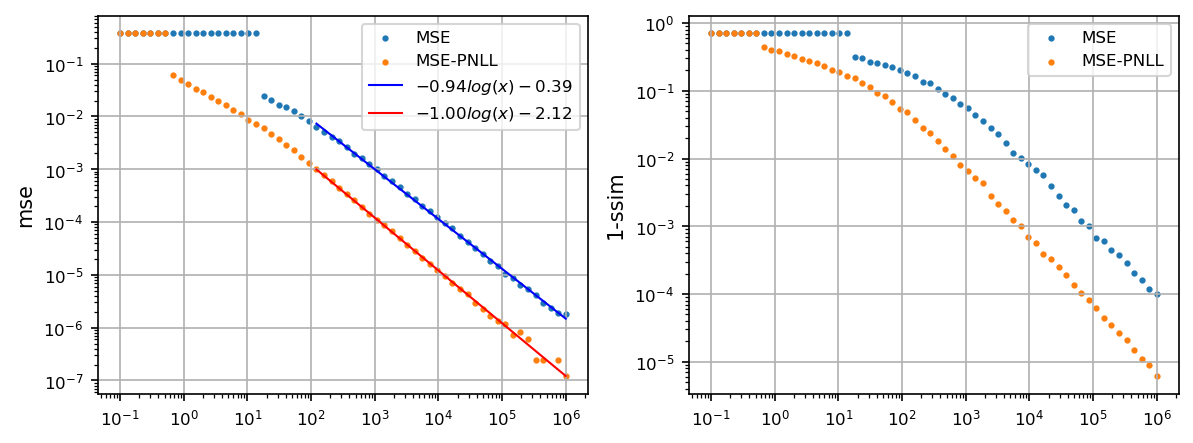

In [368]:
start = np.argwhere(fluences >= 100).min()
X_mse = np.array(fluences[start:])
y_mse = np.array(mse_dict['object_mse'][start:])
X_pnll = np.array(fluences[start:])
y_pnll = np.array(mse_dict['object_mse_nll'][start:])
# we remove one of the mse that is set to 0, since it causes problems with the log
idx_to_remove = np.argwhere(y_pnll == 0).squeeze()
X_pnll = np.delete(X_pnll, idx_to_remove)
y_pnll = np.delete(y_pnll, idx_to_remove)

# Fit linear regression in log-log space
lg_mse = LinearRegression().fit(np.log(X_mse).reshape(-1, 1), np.log(y_mse))
lg_pnll = LinearRegression().fit(np.log(X_pnll).reshape(-1, 1), np.log(y_pnll))

# Create a line based on the regression
X_fit_mse = np.linspace(min(X_mse), max(X_mse), 2)
log_X_fit_mse = np.log(X_fit_mse).reshape(-1, 1)
log_y_fit_mse = lg_mse.predict(log_X_fit_mse)
y_fit_mse = np.exp(log_y_fit_mse)

X_fit_pnll = np.linspace(min(X_pnll), max(X_pnll), 2)
log_X_fit_pnll = np.log(X_fit_pnll).reshape(-1, 1)
log_y_fit_pnll = lg_pnll.predict(log_X_fit_pnll)
y_fit_pnll = np.exp(log_y_fit_pnll)

f, ax = plt.subplots(1, 2, figsize=(8, 3))

ax[0].scatter(fluences, mse_dict['object_mse'], label='MSE', s=4)
ax[0].scatter(fluences, mse_dict['object_mse_nll'], label='MSE-PNLL', s=4)
ax[0].plot(X_fit_mse, y_fit_mse, color='blue', label=f'${lg_mse.coef_[0]:.2f}log(x){lg_mse.intercept_:.2f}$')
ax[0].plot(X_fit_pnll, y_fit_pnll, color='red', label=f'${lg_pnll.coef_[0]:.2f}log(x){lg_pnll.intercept_:.2f}$')
ax[0].set_ylabel('mse')

ax[1].scatter(fluences, 1-ssim_dict['object_mse'], label='MSE', s=4)
ax[1].scatter(fluences, 1-ssim_dict['object_mse_nll'], label='MSE-PNLL', s=4)
ax[1].set_ylabel('1-ssim')

for a in ax:
    a.set_xscale('log'), a.set_yscale('log')
    a.grid()
    a.legend()

f.tight_layout()

f.savefig('figures/fluence_variation.png', bbox_inches='tight')

# Steps sizes

In [13]:
rec_dict = {
    'object_mse': {},
    'loss_mse': {},
    'object_mse_nll': {},
    'loss_mse_nll': {}
}

for i in range(1, 31):
    loaded_dict = load_data(f'outputs/steps_size/rec_steps_{i}.pkl')
    for key, value in loaded_dict.items():
        rec_dict[key][i] = value

steps_sizes = np.array(list(rec_dict['object_mse'].keys()))
fluences = np.array(list(rec_dict['object_mse'][1].keys()))

mse_dict = {key: get_MSE_param_flu(TRUE_IMG, rec_dict[key]) for key in obj_keys}
ssim_dict = {key: get_SSIM_param_flu(TRUE_IMG, rec_dict[key]) for key in obj_keys}

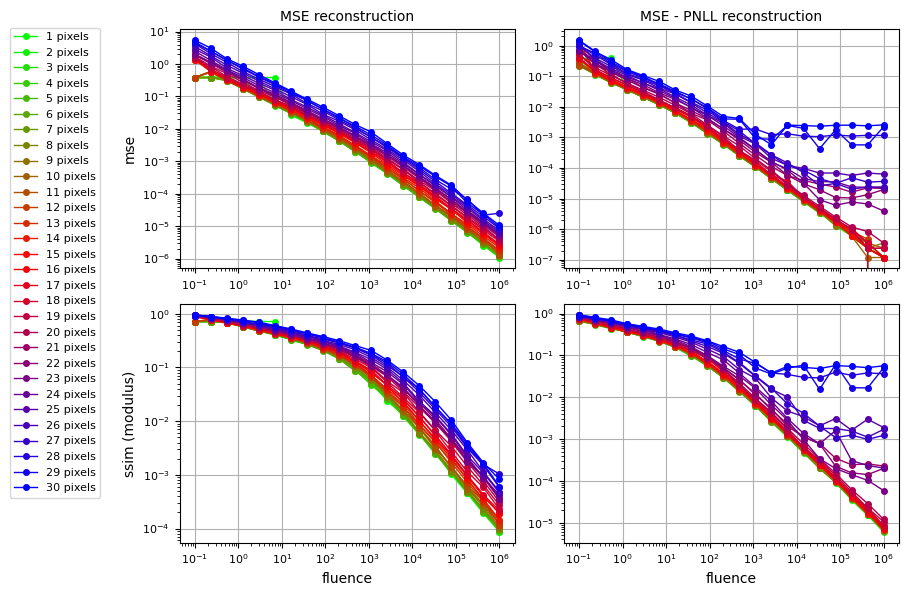

In [14]:
f = plot_metrics_params_flu(fluences, mse_dict, ssim_dict, 'steps', steps_sizes)    
# f.savefig('figures/metrics_steps.png', bbox_inches='tight')

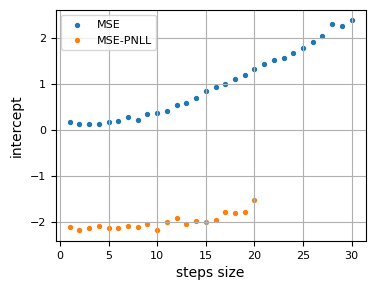

In [11]:
start = np.argwhere(fluences >= 1e3).min()
X_mse = np.log(fluences[start:])
y_list_log_mse = np.log(mse_dict['object_mse'][:, start:])
X_pnll = np.log(fluences[start:-1])
y_list_log_pnll = np.log(mse_dict['object_mse_nll'][:20, start:-1])

def rec_fit(x, b):
    return -1 * x + b

intercept_list_mse, intercept_list_pnll = [], []
for y_mse in y_list_log_mse:
    intercept_mse, _ = curve_fit(rec_fit, X_mse, y_mse)
    intercept_list_mse.append(intercept_mse)
for y_pnll in y_list_log_pnll:
    intercept_pnll, _ = curve_fit(rec_fit, X_pnll, y_pnll)
    intercept_list_pnll.append(intercept_pnll)

f, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.scatter(range(1, 31), intercept_list_mse, label=f'MSE', s=8)
ax.scatter(range(1, 21), intercept_list_pnll, label=f'MSE-PNLL', s=8)
ax.set_ylabel('intercept')
ax.set_xlabel('steps size')
ax.legend()
ax.grid()

# f.savefig('figures/intercept_steps.png', bbox_inches='tight')

In [186]:
idx_flu = np.arange(3, 10)
idx_steps = [0]

# f_amp_mse = plot_results_param_flu(
#     rec_dict['object_mse'], plot_phase, idx_steps, idx_flu, 'steps'
# )
# f_amp_mse_nll = plot_results_param_flu(
#     rec_dict['object_mse_nll'], plot_phase, idx_steps, idx_flu, 'steps'
# )

# f_amp_mse.savefig('figures/amp_steps_mse.png', bbox_inches='tight')
# f_amp_mse_nll.savefig('figures/amp_steps_msenll.png', bbox_inches='tight')

In [120]:
# f_phase_mse = plot_results_param_flu(
#     rec_dict['object_mse'], plot_phase, idx_steps, idx_flu, 'steps'
# )
# f_phase_mse_nll = plot_results_param_flu(
#     rec_dict['object_mse_nll'], plot_phase, idx_steps, idx_flu, 'steps'
# )

# f_phase_mse.savefig('figures/phase_steps_mse.png', bbox_inches='tight')
# f_phase_mse_nll.savefig('figures/phase_steps_msenll.png', bbox_inches='tight')

# Multiprobe - grad

In [20]:
weights = np.linspace([100, 0, 0], [0, 50, 50], 11)
pkl_suf = [
    np.array2string(w, separator=',').replace(' ', '').replace('.', '')
    for w in weights
]

rec_dict = {
    'object_mse': {},
    'loss_mse': {},
    'object_mse_nll': {},
    'loss_mse_nll': {}
}

for suf in pkl_suf:
    loaded_dict = load_data(f'outputs/grad/rec_grad_{suf}.pkl')
    for key, value in loaded_dict.items():
        rec_dict[key][suf] = value

modes_config = np.array(list(rec_dict['object_mse'].keys()))
fluences = np.array(list(rec_dict['object_mse'][modes_config[0]].keys()))

mse_dict = {key: get_MSE_param_flu(TRUE_IMG, rec_dict[key]) for key in obj_keys}
ssim_dict = {key: get_SSIM_param_flu(TRUE_IMG, rec_dict[key]) for key in obj_keys}

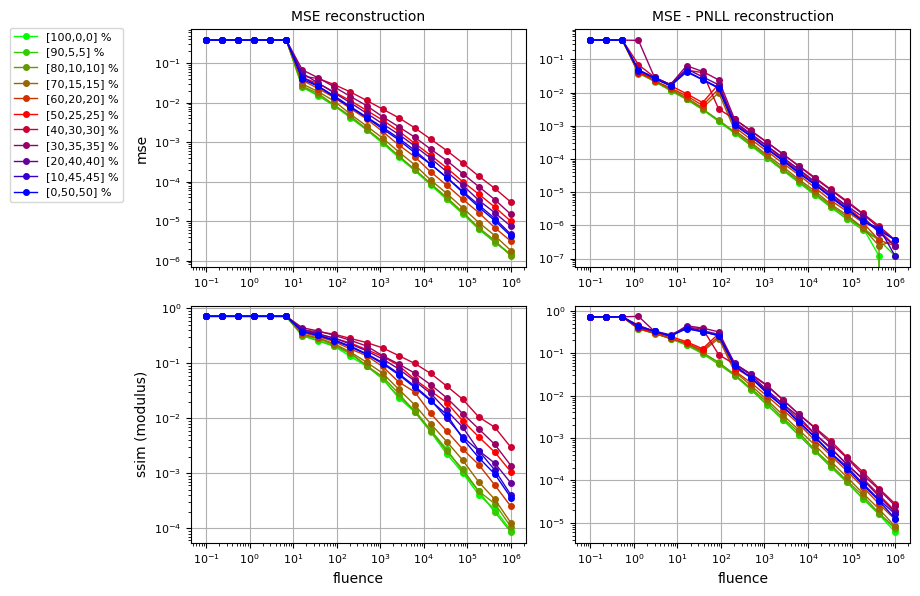

In [21]:
f = plot_metrics_params_flu(fluences, mse_dict, ssim_dict, 'grad', modes_config)
f.savefig('figures/metrics_grad.png', bbox_inches='tight')

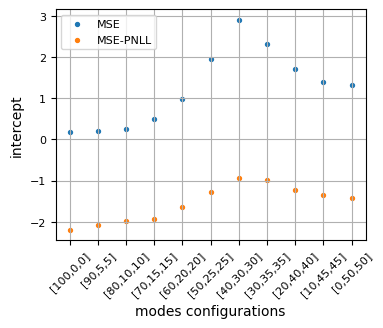

In [25]:
start = np.argwhere(fluences >= 1e3).min()
X_mse = np.log(fluences[start:])
y_list_log_mse = np.log(mse_dict['object_mse'][:, start:])
X_pnll = np.log(fluences[start:-1])
y_list_log_pnll = np.log(mse_dict['object_mse_nll'][:, start:-1])

def rec_fit(x, b):
    return -1 * x + b

intercept_list_mse, intercept_list_pnll = [], []
for y_mse in y_list_log_mse:
    intercept_mse, _ = curve_fit(rec_fit, X_mse, y_mse)
    intercept_list_mse.append(intercept_mse)
for y_pnll in y_list_log_pnll:
    intercept_pnll, _ = curve_fit(rec_fit, X_pnll, y_pnll)
    intercept_list_pnll.append(intercept_pnll)

f, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.scatter(range(11), intercept_list_mse, label=f'MSE', s=8)
ax.scatter(range(11), intercept_list_pnll, label=f'MSE-PNLL', s=8)
ax.set_xticks(range(11), modes_config, rotation=45)
ax.set_ylabel('intercept')
ax.set_xlabel('modes configurations')
ax.legend()
ax.grid()
f.savefig('figures/intercept_grad.png', bbox_inches='tight')

In [123]:
idx_flu = [5, 6, 8, 14]
idx_grad = [0, 7, 10]

# f_amp_mse = plot_results_param_flu(
#     rec_dict['object_mse'], plot_amplitude, idx_grad, idx_flu, 'grad'
# )
# f_amp_mse_nll = plot_results_param_flu(
#     rec_dict['object_mse_nll'], plot_amplitude, idx_grad, idx_flu, 'grad'
# )

# f_amp_mse.savefig('figures/amp_grad_mse.png', bbox_inches='tight')
# f_amp_mse_nll.savefig('figures/amp_grad_msenll.png', bbox_inches='tight')

In [125]:
idx_flu = [5, 6, 8, 14]
idx_grad = [0, 6, 10]

# f_phase_mse = plot_results_param_flu(
#     rec_dict['object_mse'], plot_phase, idx_grad, idx_flu, 'grad'
# )
# f_phase_mse_nll = plot_results_param_flu(
#     rec_dict['object_mse_nll'], plot_phase, idx_grad, idx_flu, 'grad'
# )

# f_phase_mse.savefig('figures/phase_grad_mse.png', bbox_inches='tight')
# f_phase_mse_nll.savefig('figures/phase_grad_msenll.png', bbox_inches='tight')

## Diffractions

In [59]:
sim_obj = simulate_object(PATH, resize=OBJ_SIZE, bc='periodic')

translations = set_scanning_grid(
    coord = (OBJ_SIZE, OBJ_SIZE),
    n_steps = OBJ_SIZE,
    steps_size = 1,
    add_noise = False
)

modes_config = np.linspace([100, 0, 0], [0, 50, 50], 11)
diff_patterns_list = []
for weights in tqdm(modes_config):
    probe = simulate_multiprobe_grad(OBJ_SIZE, 5, weights=weights)
    diff_patterns_list.append(get_diffractions_direct(probe, sim_obj, translations))

100%|██████████| 11/11 [00:15<00:00,  1.45s/it]


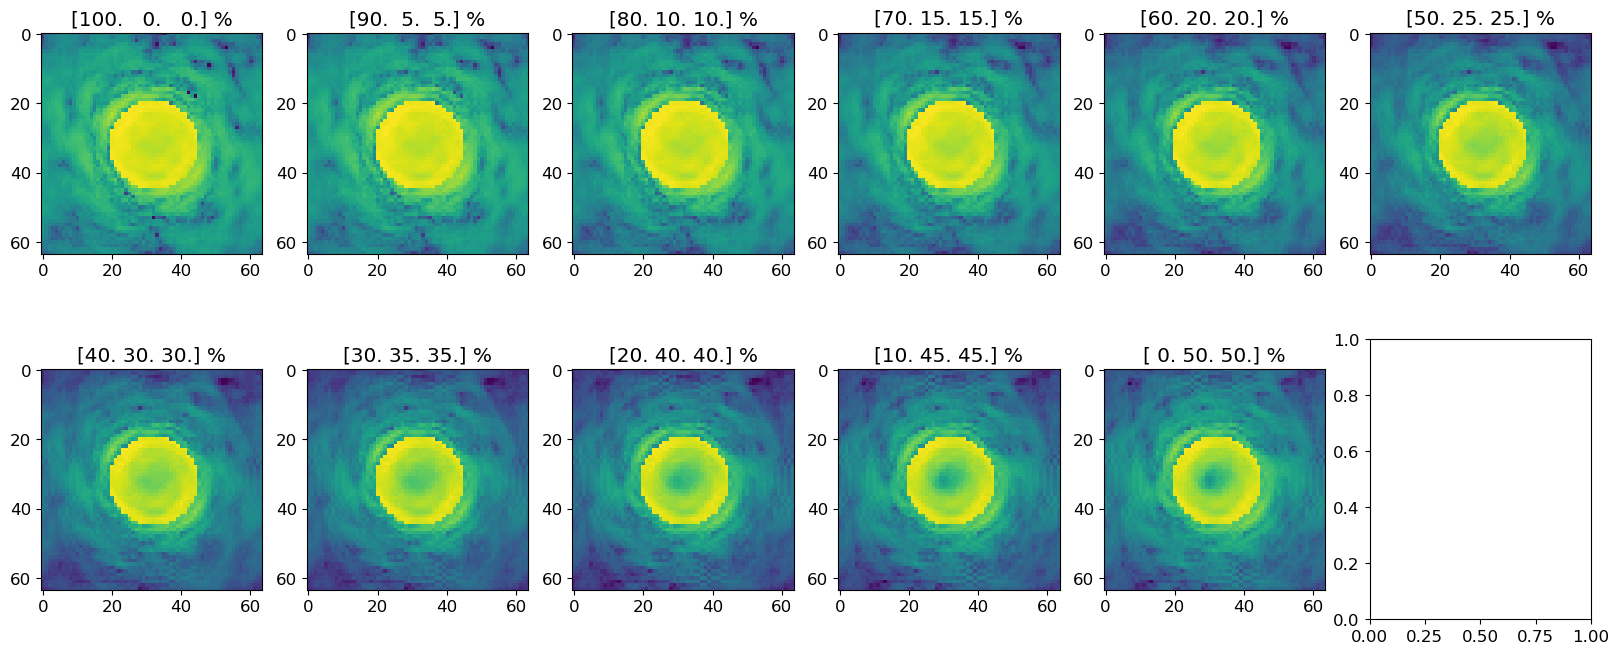

In [66]:
f, ax = plt.subplots(2, 6, figsize=(20, 8))
ax = ax.flatten()

for i, diff_pattern in enumerate(diff_patterns_list):
    ax[i].imshow(t.log10(diff_pattern[0]))
    ax[i].set_title(f'{modes_config[i]} %')

f.savefig('figures/grad_diffractions.png', bbox_inches='tight')

# Multiprobe - band limited random

In [26]:
rec_dict = {
    'object_mse': {},
    'loss_mse': {},
    'object_mse_nll': {},
    'loss_mse_nll': {}
}

for i in range(1, 11):
    loaded_dict = load_data(f'outputs/bandlim/rec_bandlim_{i}.pkl')
    for key, value in loaded_dict.items():
        rec_dict[key][i] = value

n_modes = np.array(list(rec_dict['object_mse'].keys()))
fluences = np.array(list(rec_dict['object_mse'][n_modes[0]].keys()))

mse_dict = {key: get_MSE_param_flu(TRUE_IMG, rec_dict[key]) for key in obj_keys}
ssim_dict = {key: get_SSIM_param_flu(TRUE_IMG, rec_dict[key]) for key in obj_keys}

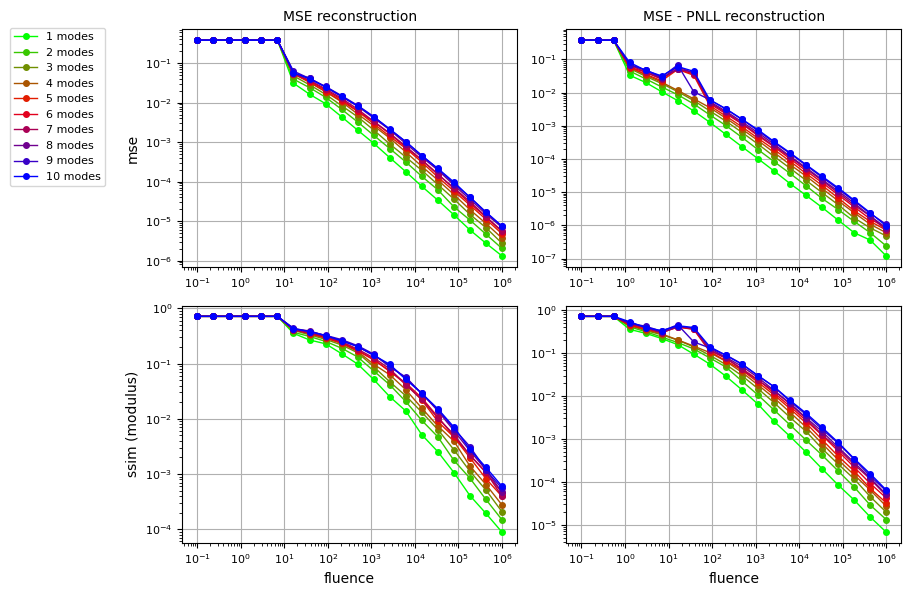

In [28]:
f = plot_metrics_params_flu(fluences, mse_dict, ssim_dict, 'band_lim', n_modes)
f.savefig('figures/metrics_bandlim.png', bbox_inches='tight')

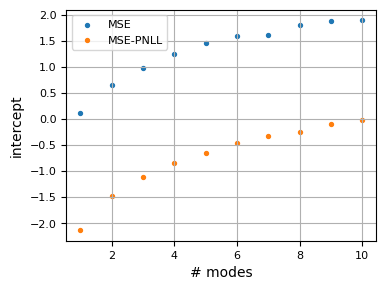

In [34]:
start = np.argwhere(fluences >= 1e3).min()
X_mse = np.log(fluences[start:])
y_list_log_mse = np.log(mse_dict['object_mse'][:, start:])
X_pnll = np.log(fluences[start:-1])
y_list_log_pnll = np.log(mse_dict['object_mse_nll'][:, start:-1])

def rec_fit(x, b):
    return -1 * x + b

intercept_list_mse, intercept_list_pnll = [], []
for y_mse in y_list_log_mse:
    intercept_mse, _ = curve_fit(rec_fit, X_mse, y_mse)
    intercept_list_mse.append(intercept_mse)
for y_pnll in y_list_log_pnll:
    intercept_pnll, _ = curve_fit(rec_fit, X_pnll, y_pnll)
    intercept_list_pnll.append(intercept_pnll)

f, ax = plt.subplots(1, 1, figsize=(4, 3))
x_axis = range(1, 11)
ax.scatter(x_axis, intercept_list_mse, label=f'MSE', s=8)
ax.scatter(x_axis, intercept_list_pnll, label=f'MSE-PNLL', s=8)
ax.set_ylabel('intercept')
ax.set_xlabel('# modes')
ax.legend()
ax.grid()

f.savefig('figures/intercept_bandlim.png', bbox_inches='tight')

In [249]:
idx_flu = [5, 6, 8, 14]
idx_bandlim = [0, 6, 9]

# f_amp_mse = plot_results_param_flu(
#     rec_dict['object_mse'], plot_amplitude, idx_bandlim, idx_flu, 'band_lim'
# )
# f_amp_mse_nll = plot_results_param_flu(
#     rec_dict['object_mse_nll'], plot_amplitude, idx_bandlim, idx_flu, 'band_lim'
# )

# f_amp_mse.savefig('figures/amp_bandlim_mse.png', bbox_inches='tight')
# f_amp_mse_nll.savefig('figures/amp_bandlim_msenll.png', bbox_inches='tight')

In [250]:
idx_flu = [5, 6, 8, 14]
idx_bandlim = [0, 6, 9]

# f_phase_mse = plot_results_param_flu(
#     rec_dict['object_mse'], plot_phase, idx_bandlim, idx_flu, 'band_lim'
# )
# f_phase_mse_nll = plot_results_param_flu(
#     rec_dict['object_mse_nll'], plot_phase, idx_bandlim, idx_flu, 'band_lim'
# )

# f_phase_mse.savefig('figures/phase_bandlim_mse.png', bbox_inches='tight')
# f_phase_mse_nll.savefig('figures/phase_bandlim_msenll.png', bbox_inches='tight')

In [251]:
idx_flu = [5, 6, 8, 14]
idx_bandlim = [0, 6, 9]

# f_phase_mse = plot_results_param_flu(
#     rec_dict['loss_mse'], plot_loss, idx_bandlim, idx_flu, 'band_lim'
# )
# f_phase_mse_nll = plot_results_param_flu(
#     rec_dict['loss_mse_nll'], plot_loss, idx_bandlim, idx_flu, 'band_lim'
# )

## Diffractions

In [5]:
from tqdm import tqdm
from tools_rec import (
    simulate_object,
    simulate_multiprobe_band_limited_random,
    set_scanning_grid, 
    get_diffractions_direct
)
from constants import OBJ_SIZE, PATH

sim_obj = simulate_object(PATH, resize=OBJ_SIZE, bc='periodic')

translations = set_scanning_grid(
    coord = (OBJ_SIZE, OBJ_SIZE),
    n_steps = OBJ_SIZE,
    steps_size = 1,
    add_noise = False
)

n_modes = range(1, 11)
diff_patterns_list = []
for n in tqdm(n_modes):
    probe = simulate_multiprobe_band_limited_random(OBJ_SIZE, 5, 0, n)
    diff_patterns_list.append(get_diffractions_direct(probe, sim_obj, translations))

/das/work/p22/p22180/conda_envs/ptycho/lib/python3.12/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1724789220573/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
  0%|          | 0/10 [00:00<?, ?it/s]/das/work/p22/p22180/conda_envs/ptycho/lib/python3.12/site-packages/skimage/draw/draw.py:48: RuntimeWarning: invalid value encountered in divide
  distances = ((r * cos_alpha + c * sin_alpha) / r_rad) ** 2 + (
/das/work/p22/p22180/conda_envs/ptycho/lib/python3.12/site-packages/skimage/draw/draw.py:49: RuntimeWarning: invalid value encountered in divide
  (r * sin_alpha - c * cos_alpha) / c_rad
100%|██████████| 10/10 [00:40<00:00,  4.10s/it]


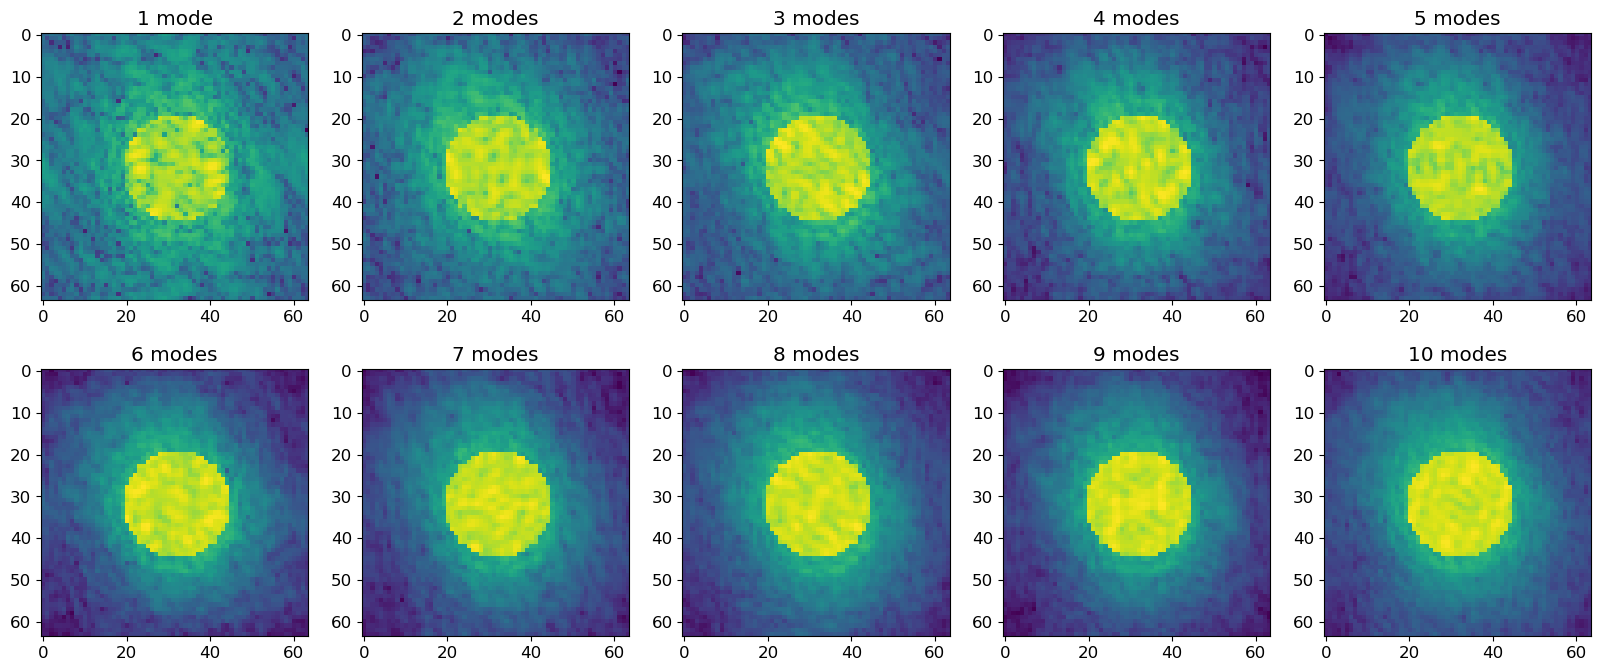

In [6]:
f, ax = plt.subplots(2, 5, figsize=(20, 8))
ax = ax.flatten()

for i, diff_pattern in enumerate(diff_patterns_list):
    ax[i].imshow(t.log10(diff_pattern[100]))
    if i == 0: ax[i].set_title('1 mode')
    else: ax[i].set_title(f'{i+1} modes')

f.savefig('figures/bandlim_diffractions.png', bbox_inches='tight')